# Tarea 7: Clasificación de Texto con Naive Bayes
## Análisis de Sentimiento en Reseñas de Películas

**Nombre:** Anthony Joel Cruz Huacon
**Fecha:** 19/06/2026

### Objetivo:
Familiarizar al estudiante con el algoritmo Naive Bayes para clasificación de texto, aplicando técnicas de preprocesamiento como Bag of Words (CountVectorizer) y TF-IDF, analizando el efecto de hiperparámetros como `alpha` (suavizado Laplaciano) y n-gramas, y evaluando el modelo mediante métricas de precisión, recall y F1-score.

### Instrucciones:
1. Ejecute cada celda de código en orden.
2. **En las celdas de código marcadas con '# TODO:', implemente el código requerido siguiendo las instrucciones.**
3. Ejecute las celdas implementadas y responda las preguntas de selección múltiple.
4. Marque sus respuestas claramente.
5. Experimente modificando hiperparámetros cuando se indique.
6. NO ELIMINAR NINGÚN COMENTARIO

### Descripción del Dataset:
Utilizaremos el dataset **Rotten Tomatoes Movie Reviews** que contiene reseñas de críticos de cine. Cada reseña está clasificada como:
- **fresh**: Reseña positiva
- **rotten**: Reseña negativa

### Archivo requerido:
- `critics.csv` - Dataset de reseñas de películas

## Parte 1: Configuración y Carga de Datos

In [104]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Configuración para gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

%matplotlib inline

print("✓ Librerías importadas exitosamente!")



✓ Librerías importadas exitosamente!


In [105]:
# TODO: Cargar el dataset critics.csv

# Instrucciones:
# 1. Use pd.read_csv('critics.csv') para cargar el dataset
critics = pd.read_csv('critics.csv')
print("******************** Datasest cargado correctamente ********************")

# 2. Imprima las dimensiones con .shape
print("\nDimensiones del dataset: ", critics.shape)

# 3. Imprima los nombres de columnas
print("\nColumnas del dataset: ")
print(critics.columns)

# 4. Muestre las primeras filas con .head()
print("\nPrimeras 5 filas: ")
print(critics.head())



******************** Datasest cargado correctamente ********************

Dimensiones del dataset:  (27631, 8)

Columnas del dataset: 
Index(['critic', 'fresh', 'imdb', 'publication', 'quote', 'review_date',
       'rtid', 'title'],
      dtype='object')

Primeras 5 filas: 
            critic  fresh    imdb           publication  \
0  Owen Gleiberman  fresh  114709  Entertainment Weekly   
1      Derek Adams  fresh  114709              Time Out   
2  Richard Corliss  fresh  114709         TIME Magazine   
3      David Ansen  fresh  114709              Newsweek   
4    Leonard Klady  fresh  114709               Variety   

                                               quote review_date  rtid  \
0                                                NaN  2011-09-07  9559   
1  So ingenious in concept, design and execution ...  2009-10-04  9559   
2                  The year's most inventive comedy.  2008-08-31  9559   
3  A winning animated feature that has something ...  2008-08-18  9559   


In [106]:
# TODO: Limpiar el dataset

# Instrucciones:
# 1. Elimine filas con quotes nulos: critics = critics[~critics.quote.isnull()]
critics = critics[~critics.quote.isnull()]

# 2. Filtre solo fresh y rotten: critics = critics[critics['fresh'].isin(['fresh', 'rotten'])]
critics = critics[critics['fresh'].isin(['fresh', 'rotten'])]

# 3. Imprima las dimensiones después de limpiar
print("Dimensiones del dataset después de limpiar: ", critics.shape)




Dimensiones del dataset después de limpiar:  (15534, 8)


### Pregunta 1: Tamaño del Dataset
¿Cuántas reseñas válidas quedan después de limpiar el dataset?

A) Aproximadamente 5,000  
B) Aproximadamente 10,000  
C) Aproximadamente 15,000  
D) Aproximadamente 20,000  

**Su Respuesta:** C) Aproximadamente 15,000

## Parte 2: Análisis Exploratorio de Datos (EDA)

In [107]:
# TODO: Explorar estadísticas básicas

# Instrucciones:
# 1. Calcule n_reviews = len(critics)
n_reviews = len(critics)

# 2. Calcule n_movies = critics.rtid.nunique()
n_movies = critics.rtid.nunique()

# 3. Calcule n_critics = critics.critic.nunique()
n_critics = critics.critic.nunique()

# 4. Imprima las estadísticas
print("****** Estadísticas básicas ******")
print("\nNúmero de reseñas:", n_reviews)
print("\nNúmero de películas:", n_movies)
print("\nNúmero de críticos:", n_critics)



****** Estadísticas básicas ******

Número de reseñas: 15534

Número de películas: 1921

Número de críticos: 621


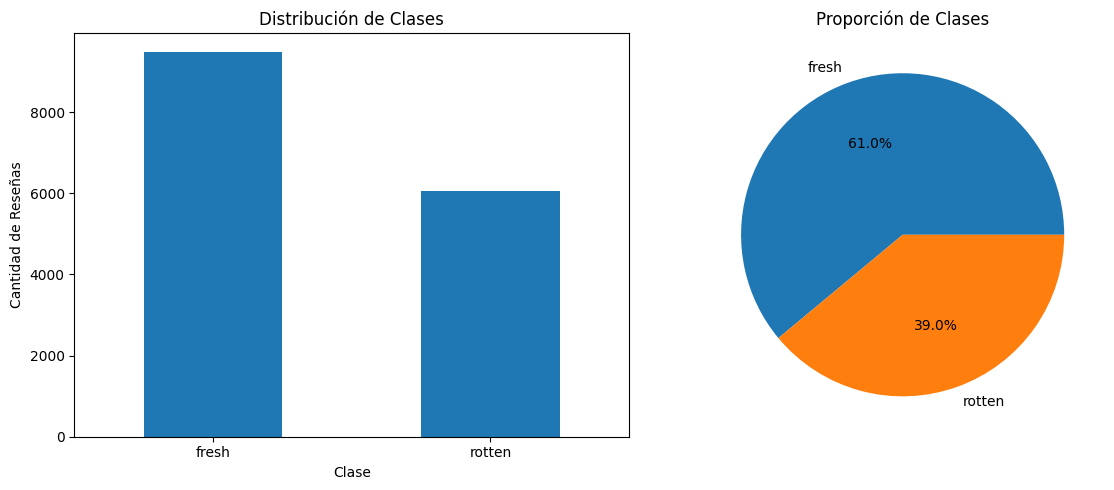


Conteo de clases:
fresh
fresh     9482
rotten    6052
Name: count, dtype: int64


In [108]:
# TODO: Visualizar distribución de clases

# Instrucciones:
# 1. Cree una figura con 2 subplots (1 fila, 2 columnas)
class_counts = critics['fresh'].value_counts()

plt.figure(figsize=(12, 5))

# 2. En el primer subplot, use critics['fresh'].value_counts().plot(kind='bar')
# Gráfico de barras
plt.subplot(1, 2, 1)
class_counts.plot(kind='bar')
plt.title('Distribución de Clases')
plt.xlabel('Clase')
plt.ylabel('Cantidad de Reseñas')
plt.xticks(rotation=0)

# 3. En el segundo subplot, use .plot(kind='pie', autopct='%1.1f%%')
# Gráfico circular
plt.subplot(1, 2, 2)
class_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Proporción de Clases')
plt.ylabel('')

# 4. Agregue títulos y etiquetas
plt.tight_layout()
plt.show()

# 5. Imprima el conteo de clases
print("\nConteo de clases:")
print(class_counts)



### Pregunta 2: Balance de Clases
¿Cuál es la clase mayoritaria en el dataset?

A) rotten (negativas)  
B) fresh (positivas)  
C) Están perfectamente balanceadas  
D) No se puede determinar  

**Su Respuesta:** B) fresh (positivas)

*** Estadísticas de longitud de caracteres ***
count    15534.000000
mean       117.014484
std         57.581577
min          4.000000
25%         72.000000
50%        114.000000
75%        158.000000
max        256.000000
Name: quote_length, dtype: float64

*** Estadísticas de número de palabras ***
count    15534.000000
mean        19.447534
std          9.792644
min          1.000000
25%         12.000000
50%         19.000000
75%         26.000000
max         49.000000
Name: word_count, dtype: float64


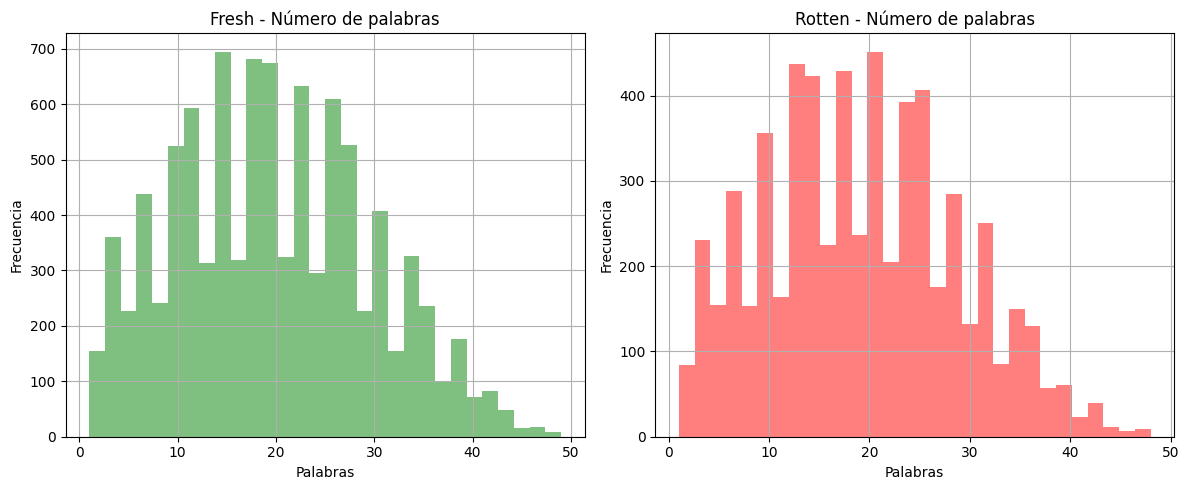

In [109]:
# TODO: Analizar longitud de las reseñas

# Instrucciones:
# 1. Cree una columna 'quote_length' con la longitud de cada quote: critics['quote'].apply(len)
critics['quote_length'] = critics['quote'].apply(len)

# 2. Cree una columna 'word_count' con el número de palabras: critics['quote'].apply(lambda x: len(str(x).split()))
critics['word_count'] = critics['quote'].apply(
    lambda x: len(str(x).split())
)

# 3. Imprima estadísticas descriptivas de estas columnas
print("*** Estadísticas de longitud de caracteres ***")
print(critics['quote_length'].describe())

print("\n*** Estadísticas de número de palabras ***")
print(critics['word_count'].describe())

# 4. Opcional: Cree histogramas comparando fresh vs rotten
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
critics[critics['fresh']=='fresh']['word_count'].hist(alpha=0.5, bins=30, color = "green")
plt.title('Fresh - Número de palabras')
plt.xlabel('Palabras')
plt.ylabel('Frecuencia')

plt.subplot(1,2,2)
critics[critics['fresh']=='rotten']['word_count'].hist(alpha=0.5, bins=30, color = "red")
plt.title('Rotten - Número de palabras')
plt.xlabel('Palabras')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()


In [110]:
# TODO: Mostrar ejemplos de reseñas

# Instrucciones:
# 1. Imprima 3 ejemplos de reseñas 'fresh' usando critics[critics['fresh']=='fresh']['quote'].head(3)
print("*************** EJEMPLOS DE RESEÑAS FRESH ***************")
print(critics[critics['fresh'] == 'fresh']['quote'].head(3))

# 2. Imprima 3 ejemplos de reseñas 'rotten'
print("\n*************** EJEMPLOS DE RESEÑAS ROTTEN ***************")
print(critics[critics['fresh'] == 'rotten']['quote'].head(3))



*************** EJEMPLOS DE RESEÑAS FRESH ***************
1    So ingenious in concept, design and execution ...
2                    The year's most inventive comedy.
3    A winning animated feature that has something ...
Name: quote, dtype: object

*************** EJEMPLOS DE RESEÑAS ROTTEN ***************
30    A gloomy special-effects extravaganza filled w...
37                               Mediocre, regrettably.
40    The movie is too pat and practiced to really b...
Name: quote, dtype: object


## Parte 3: Preprocesamiento de Texto - Bag of Words

### Teoría:
El modelo **Bag of Words (BoW)** representa el texto como un vector de frecuencias de palabras, ignorando el orden. **CountVectorizer** de Scikit-Learn implementa este enfoque.

$$\text{Vector} = [\text{count}(w_1), \text{count}(w_2), ..., \text{count}(w_n)]$$

In [111]:
# TODO: Crear una función para preparar los datos
#
# Instrucciones:
# 1. Defina la función make_xy(data, vectorizer) que:
#    a. Aplique vectorizer.fit_transform(data['quote']) para obtener X
#    b. Convierta 'fresh' a binario: y = (data['fresh'] == 'fresh').astype(int).values
#    c. Retorne X, y

def make_xy(data, vectorizer):

    X = vectorizer.fit_transform(data['quote'])

    y = (data['fresh'] == 'fresh').astype(int).values

    return X, y

    pass


In [112]:
# TODO: Aplicar CountVectorizer
#
# Instrucciones:
# 1. Cree vectorizer = CountVectorizer(min_df=5)
# 2. Use make_xy() para obtener X, y
# 3. Imprima la forma de X y y
# 4. Imprima algunos ejemplos de palabras del vocabulario con vectorizer.get_feature_names_out()[:20]

vectorizer = CountVectorizer(min_df=5)

X, y = make_xy(critics, vectorizer)

print("\n***** Formas de x, y *****")
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

print("\n*************** Primeras 20 palabras del vocabulario: ***************")
print(vectorizer.get_feature_names_out()[:20])




***** Formas de x, y *****
Forma de X: (15534, 6166)
Forma de y: (15534,)

*************** Primeras 20 palabras del vocabulario: ***************
['000' '007' '10' '100' '11' '12' '13' '13th' '15' '16' '17' '1930s'
 '1933' '1939' '1940s' '1950s' '1956' '1960s' '1961' '1963']


### Pregunta 3: Dimensiones del Vocabulario
¿Aproximadamente cuántas características (palabras únicas) tiene el vocabulario con min_df=5?

A) 500-1,000  
B) 1,000-5,000  
C) 5,000-10,000  
D) 10,000-20,000  

**Su Respuesta:** C) 5,000-10,000

In [113]:
# TODO: Dividir en train y test
#
# Instrucciones:
# 1. Use train_test_split(X, y, test_size=0.3, random_state=42)
# 2. Asigne a X_train, X_test, y_train, y_test
# 3. Imprima los tamaños de cada conjunto
# 4. Imprima la distribución de clases en entrenamiento

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print("\nTamaños de los conjuntos train y test")
print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\n\nDistribución de las clase en entrenamiento")
print(pd.Series(y_train).value_counts())




Tamaños de los conjuntos train y test
Train: (10873, 6166)
Test: (4661, 6166)


Distribución de las clase en entrenamiento
1    6623
0    4250
Name: count, dtype: int64


## Parte 4: Naive Bayes Multinomial

### Teoría - Teorema de Bayes:
$$P(C|X) = \frac{P(X|C) \cdot P(C)}{P(X)}$$

**Naive Bayes** asume independencia condicional entre características:
$$P(X|C) = P(x_1|C) \cdot P(x_2|C) \cdot ... \cdot P(x_n|C)$$

**Multinomial Naive Bayes** es apropiado para conteos de palabras.

In [114]:
# TODO: Entrenar Multinomial Naive Bayes
#
# Instrucciones:
# 1. Cree el modelo: clf_nb = MultinomialNB()
# 2. Entrene con clf_nb.fit(X_train, y_train)
# 3. Prediga en train y test
# 4. Calcule y muestre las precisiones en train y test con accuracy_score()

# modelo clf_nb
clf_nb = MultinomialNB()

clf_nb.fit(X_train, y_train)

y_pred_train = clf_nb.predict(X_train)
y_pred_test = clf_nb.predict(X_test)

print("Precisiones en train y test utilizando accuracy_score")
print("Accuracy Train:", accuracy_score(y_train, y_pred_train))
print("Accuracy Test:", accuracy_score(y_test, y_pred_test))



Precisiones en train y test utilizando accuracy_score
Accuracy Train: 0.8708728041938747
Accuracy Test: 0.7670027891010512


### Pregunta 4: Precisión del Modelo Base
¿Cuál es la precisión aproximada del modelo Naive Bayes en el conjunto de prueba?

A) 60-70%  
B) 70-80%  
C) 80-90%  
D) 90-100%  

**Su Respuesta:** B) 70-80%

## Parte 5: Matriz de Confusión y Métricas

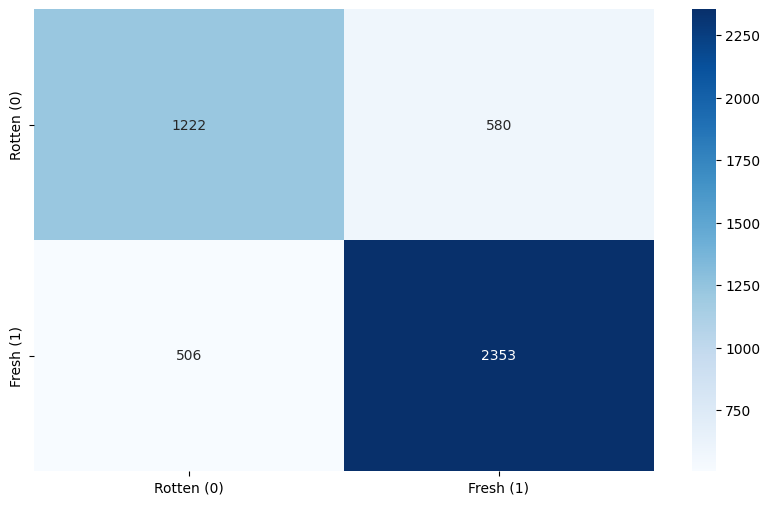


TN: 1222
FP: 580
FN: 506
TP: 2353


In [115]:
# TODO: Calcular y visualizar la matriz de confusión
#
# Instrucciones:
# 1. Calcule cm = confusion_matrix(y_test, y_pred_test)
# 2. Visualice con sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# 3. Configure xticklabels y yticklabels como ['Rotten (0)', 'Fresh (1)']
# 4. Imprima TN, FP, FN, TP

cm = confusion_matrix(y_test, y_pred_test)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rotten (0)", "Fresh (1)"],
    yticklabels=["Rotten (0)", "Fresh (1)"]
)

plt.show()

tn, fp, fn, tp = cm.ravel()

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)



In [116]:
# TODO: Calcular métricas detalladas
#
# Instrucciones:
# 1. Calcule precision = precision_score(y_test, y_pred_test)
# 2. Calcule recall = recall_score(y_test, y_pred_test)
# 3. Calcule f1 = f1_score(y_test, y_pred_test)
# 4. Imprima las métricas
# 5. Use classification_report() para el reporte completo

precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print("\nResultados de las métricas")
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print(classification_report(y_test, y_pred_test))



Resultados de las métricas
Precision: 0.8022502557108763
Recall: 0.8230150402238545
F1: 0.8125
              precision    recall  f1-score   support

           0       0.71      0.68      0.69      1802
           1       0.80      0.82      0.81      2859

    accuracy                           0.77      4661
   macro avg       0.75      0.75      0.75      4661
weighted avg       0.77      0.77      0.77      4661



### Pregunta 5: Interpretación de Métricas
Si el modelo tiene alto recall pero baja precisión para la clase 'Fresh', ¿qué significa?

A) El modelo detecta bien las reseñas positivas pero también clasifica muchas negativas como positivas  
B) El modelo no detecta las reseñas positivas  
C) El modelo es perfecto  
D) El modelo solo predice negativas  

**Su Respuesta:** A) El modelo detecta bien las reseñas positivas pero también clasifica muchas negativas como positivas

## Parte 6: Efecto del Parámetro Alpha (Suavizado Laplaciano)

### Teoría:
El parámetro `alpha` es el **suavizado de Laplace** (additive smoothing). Evita probabilidades de cero para palabras no vistas:

$$P(w|C) = \frac{\text{count}(w,C) + \alpha}{\text{count}(C) + \alpha \cdot |V|}$$

- alpha=1.0: Suavizado estándar (default)
- alpha<1.0: Menos suavizado
- alpha>1.0: Más suavizado

In [117]:
# TODO: Experimentar con diferentes valores de alpha
#
# Instrucciones:
# 1. Defina alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
# 2. Para cada alpha:
#    a. Cree MultinomialNB(alpha=alpha)
#    b. Entrene y calcule precisiones train/test
#    c. Calcule precision y recall
# 3. Guarde resultados en un DataFrame e imprima

alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

results = []

for alpha in alphas:

    model = MultinomialNB(alpha=alpha)

    model.fit(X_train, y_train)

    train_acc = accuracy_score(
        y_train,
        model.predict(X_train)
    )

    test_acc = accuracy_score(
        y_test,
        model.predict(X_test)
    )

    results.append(
        [alpha, train_acc, test_acc]
    )

results_df = pd.DataFrame(
    results,
    columns=["alpha","train_acc","test_acc"]
)

print(results_df)



    alpha  train_acc  test_acc
0   0.001   0.884668  0.751555
1   0.010   0.884117  0.754988
2   0.100   0.880898  0.761854
3   0.500   0.876759  0.764643
4   1.000   0.870873  0.767003
5   2.000   0.863975  0.768934
6   5.000   0.839787  0.755203
7  10.000   0.766302  0.714010


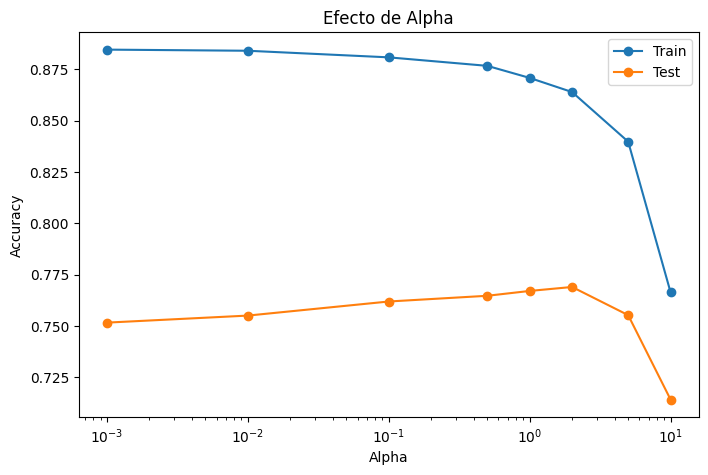

In [118]:
# TODO: Visualizar el efecto de alpha
#
# Instrucciones:
# 1. Grafique train_scores y test_scores vs alphas
# 2. Use plt.xscale('log') para escala logarítmica
# 3. Agregue leyenda, título y etiquetas

plt.figure(figsize=(8,5))

plt.plot(
    results_df["alpha"],
    results_df["train_acc"],
    marker="o",
    label="Train"
)

plt.plot(
    results_df["alpha"],
    results_df["test_acc"],
    marker="o",
    label="Test"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.title("Efecto de Alpha")
plt.legend()

plt.show()


### Pregunta 6: Efecto de Alpha
¿Qué ocurre cuando alpha es muy pequeño (ej: 0.001)?

A) El modelo generaliza mejor  
B) El modelo tiende a sobreajustar (train acc >> test acc)  
C) El modelo no aprende nada  
D) No hay efecto significativo  

**Su Respuesta:** B) El modelo tiende a sobreajustar (train acc >> test acc)

## Parte 7: N-gramas

### Teoría:
Los **n-gramas** capturan secuencias de n palabras consecutivas:
- Unigrama (1-gram): palabras individuales
- Bigrama (2-gram): pares de palabras
- Trigrama (3-gram): tríos de palabras

Ejemplo: "I love this movie"
- Unigramas: ["I", "love", "this", "movie"]
- Bigramas: ["I love", "love this", "this movie"]

In [119]:
# TODO: Experimentar con diferentes n-gramas
#
# Instrucciones:
# 1. Defina ngram_configs = [(1,1), (1,2), (2,2), (1,3), (2,3)]
# 2. Para cada configuración:
#    a. Cree CountVectorizer(ngram_range=ngram, min_df=5)
#    b. Use make_xy() para crear X, y
#    c. Divida en train/test
#    d. Entrene MultinomialNB y calcule precisiones
# 3. Imprima los resultados comparativos

ngram_configs = [(1,1),(1,2),(2,2),(1,3),(2,3)]

print("Resultados comparativos")

for ngram in ngram_configs:

    vec = CountVectorizer(
        ngram_range=ngram,
        min_df=5
    )

    X_ng, y_ng = make_xy(critics, vec)

    Xtr, Xte, ytr, yte = train_test_split(
        X_ng,
        y_ng,
        test_size=0.3,
        random_state=42
    )

    model = MultinomialNB()

    model.fit(Xtr, ytr)

    acc = accuracy_score(
        yte,
        model.predict(Xte)
    )
    print(ngram, "->", acc)



Resultados comparativos
(1, 1) -> 0.7670027891010512
(1, 2) -> 0.7719373524994636
(2, 2) -> 0.6895515983694486
(1, 3) -> 0.7659300579274834
(2, 3) -> 0.6803261102767646


### Pregunta 7: N-gramas
¿Qué ocurre al usar solo bigramas (2,2) en comparación con unigramas (1,1)?

A) Siempre mejora la precisión  
B) Aumenta mucho el número de características y puede sobreajustar  
C) Reduce el número de características  
D) No tiene ningún efecto  

**Su Respuesta:** B) Aumenta mucho el número de características y puede sobreajustar

## Parte 8: TF-IDF

### Teoría:
**TF-IDF** (Term Frequency - Inverse Document Frequency) pondera las palabras por su importancia:

$$\text{TF-IDF}(t,d) = \text{TF}(t,d) \times \text{IDF}(t)$$

Donde:
- TF(t,d): Frecuencia del término t en el documento d
- IDF(t): log(N / df(t)) - penaliza palabras muy comunes

In [120]:
# TODO: Aplicar TF-IDF
#
# Instrucciones:
# 1. Cree tfidf_vectorizer = TfidfVectorizer(min_df=5, stop_words='english')
# 2. Use make_xy() para crear X_tfidf, y_tfidf
# 3. Divida en train/test
# 4. Entrene MultinomialNB
# 5. Calcule y muestre precisiones train/test

tfidf_vectorizer = TfidfVectorizer(
    min_df=5,
    stop_words="english"
)

X_tfidf, y_tfidf = make_xy(
    critics,
    tfidf_vectorizer
)

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf,
    y_tfidf,
    test_size=0.3,
    random_state=42
)

clf_tfidf = MultinomialNB()

clf_tfidf.fit(
    X_train_tfidf,
    y_train_tfidf
)

print("Precisiones de train y test")
print(
    "Train:",
    accuracy_score(
        y_train_tfidf,
        clf_tfidf.predict(X_train_tfidf)
    )
)

print(
    "Test:",
    accuracy_score(
        y_test_tfidf,
        clf_tfidf.predict(X_test_tfidf)
    )
)



Precisiones de train y test
Train: 0.8458567092798676
Test: 0.742544518343703


In [121]:
# TODO: Imprimir reporte de clasificación con TF-IDF
#
# Instrucciones:
# 1. Prediga con el modelo TF-IDF
# 2. Use classification_report() para el reporte

print("Reporte de clasificación con TF -IDF")
pred_tfidf = clf_tfidf.predict(X_test_tfidf)

print(classification_report(y_test_tfidf, pred_tfidf))



Reporte de clasificación con TF -IDF
              precision    recall  f1-score   support

           0       0.79      0.46      0.58      1802
           1       0.73      0.92      0.81      2859

    accuracy                           0.74      4661
   macro avg       0.76      0.69      0.70      4661
weighted avg       0.75      0.74      0.72      4661



### Pregunta 8: TF-IDF vs CountVectorizer
¿Cuál es una ventaja de TF-IDF sobre CountVectorizer simple?

A) Siempre da mejor precisión  
B) Penaliza palabras muy comunes y reduce el sobreajuste  
C) Usa menos memoria  
D) Es más rápido de calcular  

**Su Respuesta:** B) Penaliza palabras muy comunes y reduce el sobreajuste

## Parte 9: Interpretación del Modelo

In [122]:
# TODO: Identificar las palabras más predictivas
#
# Instrucciones:
# 1. Obtenga los nombres de características: feature_names = np.array(vectorizer.get_feature_names_out())
# 2. Obtenga log probabilidades: clf_nb.feature_log_prob_[1] (Fresh) y clf_nb.feature_log_prob_[0] (Rotten)
# 3. Calcule la diferencia: log_ratio = log_prob_fresh - log_prob_rotten
# 4. Use argsort() para encontrar las 15 palabras más positivas y negativas
# 5. Imprima las palabras con sus log ratios

feature_names = np.array(
    vectorizer.get_feature_names_out()
)

log_prob_fresh = clf_nb.feature_log_prob_[1]
log_prob_rotten = clf_nb.feature_log_prob_[0]

log_ratio = log_prob_fresh - log_prob_rotten

top_positive = np.argsort(log_ratio)[-15:]
top_negative = np.argsort(log_ratio)[:15]

print("Palabras positivas:")
print(feature_names[top_positive])

print("\nPalabras negativas:")
print(feature_names[top_negative])



Palabras positivas:
['childhood' 'myth' 'kurosawa' 'irresistible' 'touching' 'intimate'
 'winning' 'innocence' 'gentle' 'rousing' 'captures' 'bold' 'richly'
 'superb' 'delight']

Palabras negativas:
['lame' 'pointless' 'uninspired' 'unfortunately' 'unfunny' 'witless'
 'charmless' 'repetitive' 'monotonous' 'resembles' 'forgettable'
 'unsatisfying' 'bland' 'fault' 'besson']


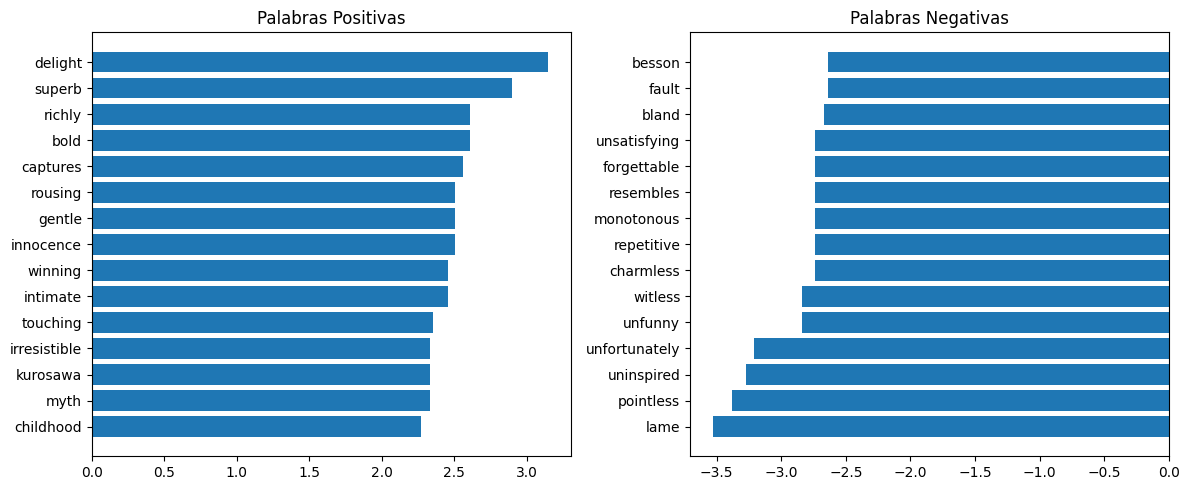

In [123]:
# TODO: Visualizar las palabras más predictivas
#
# Instrucciones:
# 1. Cree una figura con 2 subplots (1 fila, 2 columnas)
# 2. En el primer subplot, grafique las palabras más positivas con barh()
# 3. En el segundo subplot, grafique las palabras más negativas
# 4. Agregue títulos y etiquetas

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.barh(
    feature_names[top_positive],
    log_ratio[top_positive]
)
plt.title("Palabras Positivas")

plt.subplot(1,2,2)
plt.barh(
    feature_names[top_negative],
    log_ratio[top_negative]
)
plt.title("Palabras Negativas")

plt.tight_layout()
plt.show()



### Pregunta 9: Interpretabilidad
¿Qué tipo de palabras esperaría encontrar asociadas a reseñas negativas?

A) Palabras como "excellent", "amazing", "brilliant"  
B) Palabras como "boring", "bad", "disappointing"  
C) Palabras neutrales como "the", "and", "is"  
D) Nombres de actores  

**Su Respuesta:** B) Palabras como "boring", "bad", "disappointing"

## Parte 10: Predicción con Nuevas Reseñas

In [124]:
# TODO: Probar el modelo con nuevas reseñas
#
# Instrucciones:
# 1. Defina una lista de nuevas reseñas de ejemplo
# 2. Transforme con vectorizer.transform(new_reviews)
# 3. Prediga con clf_nb.predict()
# 4. Obtenga probabilidades con clf_nb.predict_proba()
# 5. Imprima cada reseña con su predicción y probabilidades

new_reviews = [
    "This movie is absolutely amazing! Best film of the year!",
    "Terrible waste of time. Boring and predictable.",
    "A decent film with good performances but weak plot.",
    "Masterpiece! Incredible acting and stunning visuals.",
    "I've seen better. Nothing special about this one."
]

X_new = vectorizer.transform(new_reviews)

preds = clf_nb.predict(X_new)

probs = clf_nb.predict_proba(X_new)

print("Reseñas con su predicción y probabilidades")

for review, pred, prob in zip(
    new_reviews,
    preds,
    probs
):

    print("\nReseña:")
    print(review)

    print(
        "Predicción:",
        "Fresh" if pred == 1 else "Rotten"
    )

    print("Probabilidades:", prob)



Reseñas con su predicción y probabilidades

Reseña:
This movie is absolutely amazing! Best film of the year!
Predicción: Fresh
Probabilidades: [0.02491136 0.97508864]

Reseña:
Terrible waste of time. Boring and predictable.
Predicción: Rotten
Probabilidades: [0.98483074 0.01516926]

Reseña:
A decent film with good performances but weak plot.
Predicción: Fresh
Probabilidades: [0.45235771 0.54764229]

Reseña:
Masterpiece! Incredible acting and stunning visuals.
Predicción: Fresh
Probabilidades: [0.00493977 0.99506023]

Reseña:
I've seen better. Nothing special about this one.
Predicción: Rotten
Probabilidades: [0.6573179 0.3426821]


### Pregunta 10: Predicciones
¿Qué método se usa para obtener las probabilidades de cada clase?

A) predict()  
B) predict_proba()  
C) score()  
D) fit()  

**Su Respuesta:** B) predict_proba()

## Parte 11: Comparación de Modelos

In [125]:
# TODO: Comparar Multinomial vs Bernoulli Naive Bayes
#
# Instrucciones:
# 1. Cree y entrene BernoulliNB() con los mismos datos
# 2. Calcule precisiones train/test
# 3. Cree un DataFrame comparando:
#    - Multinomial NB
#    - Bernoulli NB
#    - Multinomial + TF-IDF
# 4. Imprima la tabla comparativa

bernoulli = BernoulliNB()

bernoulli.fit(X_train, y_train)

bernoulli_test = accuracy_score(
    y_test,
    bernoulli.predict(X_test)
)

multinomial_test = accuracy_score(
    y_test,
    y_pred_test
)

tfidf_test = accuracy_score(
    y_test_tfidf,
    clf_tfidf.predict(X_test_tfidf)
)

comparison = pd.DataFrame({
    "Modelo":[
        "Multinomial NB",
        "Bernoulli NB",
        "Multinomial + TFIDF"
    ],
    "Accuracy":[
        multinomial_test,
        bernoulli_test,
        tfidf_test
    ]
})

print("Tabla comparativa de los modelos (Multinomial vs Bernoulli)")
print(comparison)



Tabla comparativa de los modelos (Multinomial vs Bernoulli)
                Modelo  Accuracy
0       Multinomial NB  0.767003
1         Bernoulli NB  0.769577
2  Multinomial + TFIDF  0.742545


### Pregunta 11: Multinomial vs Bernoulli
¿Cuál es la diferencia principal entre Multinomial y Bernoulli Naive Bayes?

A) No hay diferencia  
B) Multinomial usa conteos de palabras, Bernoulli usa presencia/ausencia binaria  
C) Bernoulli es siempre mejor  
D) Multinomial solo funciona con TF-IDF  

**Su Respuesta:** B) Multinomial usa conteos de palabras, Bernoulli usa presencia/ausencia binaria

### Pregunta 12: Suposición de Naive Bayes
¿Cuál es la suposición principal del algoritmo Naive Bayes?

A) Las características tienen distribución normal  
B) Las características son independientes dada la clase  
C) Los datos deben estar normalizados  
D) Debe haber balance de clases  

**Su Respuesta:** B) Las características son independientes dada la clase

### Pregunta 13: Ventajas de Naive Bayes
¿Cuál es una ventaja de Naive Bayes para clasificación de texto?

A) Siempre da la mejor precisión  
B) Es rápido de entrenar y funciona bien con alta dimensionalidad  
C) No requiere preprocesamiento  
D) Captura relaciones complejas entre palabras  

**Su Respuesta:** B) Es rápido de entrenar y funciona bien con alta dimensionalidad

### Pregunta 14: Stop Words
¿Qué son las "stop words" en procesamiento de texto?

A) Palabras con errores ortográficos  
B) Palabras muy comunes que aportan poca información (the, is, and)  
C) Palabras negativas  
D) Palabras técnicas  

**Su Respuesta:** B) Palabras muy comunes que aportan poca información (the, is, and)

### Pregunta 15: min_df en CountVectorizer
¿Qué hace el parámetro min_df=5 en CountVectorizer?

A) Limita a 5 palabras por documento  
B) Ignora palabras que aparecen en menos de 5 documentos  
C) Usa solo las 5 palabras más frecuentes  
D) Divide los datos en 5 partes  

**Su Respuesta:** B) Ignora palabras que aparecen en menos de 5 documentos

## ¡Excelente Trabajo!

Responda las preguntas basadas en sus ejecuciones. Entregue el notebook completado con todas las celdas ejecutadas.